In [1]:
import pandas as pd 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
# Dataset: Hours Slept & Coffee Drank vs Pass/Fail (1=Pass, 0=Fail) 
data = { 
 'Hours_Sleep': [8, 7, 6, 5, 8, 4, 9, 5, 6, 4], 
 'Coffee_Cups': [1, 2, 2, 4, 0, 5, 1, 4, 3, 6], 
 'Passed': [1, 1, 1, 0, 1, 0, 1, 0, 0, 0] 
} 
df = pd.DataFrame(data) 
X = df[['Hours_Sleep', 'Coffee_Cups']] 
y = df['Passed'] 
# Split the data 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 
# Train the Classifier 
clf = LogisticRegression() 
clf.fit(X_train, y_train)
print("Model Prediction for Test Data:", clf.predict(X_test)) 


Model Prediction for Test Data: [0 1]


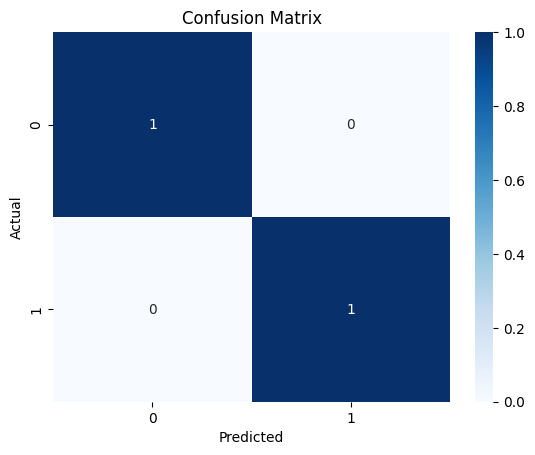

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [3]:
from sklearn.metrics import confusion_matrix, classification_report 
import seaborn as sns 
import matplotlib.pyplot as plt 
y_pred = clf.predict(X_test) 
cm = confusion_matrix(y_test, y_pred) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues') 
plt.xlabel('Predicted') 
plt.ylabel('Actual') 
plt.title('Confusion Matrix') 
plt.show() 
print(classification_report(y_test, y_pred)) 


In [5]:
# The 'coefficients' tell us the importance of each feature 
importance = clf.coef_[0] 
for i, v in enumerate(importance): 
 print(f'Feature: {X.columns[i]}, Score: {v:.4f}') 


Feature: Hours_Sleep, Score: 0.6322
Feature: Coffee_Cups, Score: -0.9367


### The Prediction Challenge

In [7]:
sample = pd.DataFrame([[3, 7]], columns=['Hours_Sleep', 'Coffee_Cups'])
print("Prediction (3h sleep, 7 coffee):", clf.predict(sample))

Prediction (3h sleep, 7 coffee): [0]


The model predicts [0] for the input (3 hours of sleep and 7 cups of coffee). This means the person is classified as Fail. Based on the model, low sleep and high coffee consumption are associated with a lower chance of passing.

### Reflect
In a cancer detection AI, a False Negative is more dangerous. This occurs when the model predicts that a patient does not have cancer when they actually do. Such an error can delay diagnosis and treatment, allowing the disease to progress and potentially become life-threatening.

On the other hand, a False Positive means the model predicts cancer when it is not present. While this can cause stress and may lead to additional tests, it can usually be corrected with further medical examination. Therefore, False Negatives are considered more harmful because they directly risk the patient’s life.

### Checklist Completion:
- Successfully trained a Logistic Regression model on the dataset.
- Generated and visualized the Confusion Matrix to evaluate model performance.
- Printed the classification report including Precision, Recall, and F1-score.
- Tested the model using custom input values to observe predictions.